In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (log_loss)
import joblib
from tfm_segunda.evaluate_models import evaluar_modelo, graficar_matriz_confusion
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import warnings

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [16]:
dataset_path = DATA_PROCESSED / "dataset_modelado.parquet"
df = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nFilas por split:")
print(df['split'].value_counts())

Dataset cargado: 7,295 filas × 41 columnas

Filas por split:
split
train         4592
validation    1373
test           923
demo           407
Name: count, dtype: int64


In [17]:
train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
test = df[df['split'] == 'test'].copy()

print(f"Train:      {len(train):>5,} filas  |  fechas {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(validation):>5,} filas  |  fechas {validation['date'].min().date()} → {validation['date'].max().date()}")
print(f"Test:       {len(test):>5,} filas  |  fechas {test['date'].min().date()} → {test['date'].max().date()}")

Train:      4,592 filas  |  fechas 2010-08-27 → 2020-08-07
Validation: 1,373 filas  |  fechas 2020-09-12 → 2023-05-28
Test:         923 filas  |  fechas 2023-08-11 → 2025-06-01


In [18]:
META_COLS = ['split', 'season', 'date', 'jornada', 'home_team', 'away_team', 'fthg', 'ftag']
TARGET_COLS = ['ftr']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

def preparar_xy(particion, feature_cols):
    mask_completas = particion[feature_cols].notna().all(axis=1)
    p = particion.loc[mask_completas].copy()
    
    X = p[feature_cols].astype(float)
    y = p['ftr']
    return X, y


X_train, y_train = preparar_xy(train, FEATURE_COLS)
X_val, y_val = preparar_xy(validation, FEATURE_COLS)
X_test, y_test = preparar_xy(test, FEATURE_COLS)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (4482, 32), y_train: (4482,)
X_val: (1338, 32), y_val: (1338,)
X_test: (901, 32), y_test: (901,)


In [19]:
scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS,
    index=X_train.index,
)
X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=FEATURE_COLS,
    index=X_val.index,
)
X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS,
    index=X_test.index,
)

In [20]:
param_grid_balanced = {
    'C':            [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0, 100.0],
    'l1_ratio':     [0.0],
    'solver':       ['lbfgs', 'saga'],
    'class_weight': ['balanced'],
    'max_iter':     [5000],
}

param_grid = {
    'C':            [1e-5, 1e-4, 1e-3, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'l1_ratio':     [0.0],
    'solver':       ['lbfgs', 'saga'],
    'class_weight': [None],
    'max_iter':     [5000],
}

In [21]:
gs = GridSearchCV(
    estimator   = LogisticRegression(),
    param_grid  = param_grid,
    cv          = TimeSeriesSplit(n_splits=5),
    scoring     = 'neg_log_loss',
    n_jobs      = -1,
    verbose     = 1,
    refit       = True,
)
gs.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.0001, ...], 'class_weight': [None], 'l1_ratio': [0.0], 'max_iter': [5000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and paramete

In [22]:

gs_balanced = GridSearchCV(
    estimator   = LogisticRegression(),
    param_grid  = param_grid_balanced,
    cv          = TimeSeriesSplit(n_splits=5),
    scoring     = 'neg_log_loss',
    n_jobs      = -1, 
    verbose     = 1,
    refit       = True,
)

gs_balanced.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1e-05, 0.0001, ...], 'class_weight': ['balanced'], 'l1_ratio': [0.0], 'max_iter': [5000], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [ ]:
logreg = gs.best_estimator_
balanced_logreg = gs_balanced.best_estimator_

In [24]:
LABELS = ['A', 'D', 'H']

def evaluar_split(nombre, X, y, lr):
    y_pred = lr.predict(X)
    y_proba = pd.DataFrame(
        lr.predict_proba(X),
        columns=lr.classes_,
    )[LABELS].values
    return evaluar_modelo(y, y_pred, y_proba, f'Logistic Regression · {nombre}')


resultado_train = evaluar_split('Train',      X_train, y_train, logreg)
resultado_val   = evaluar_split('Validation', X_val,   y_val, logreg)
resultado_test  = evaluar_split('Test',       X_test,  y_test, logreg)


resultado_train_balanced = evaluar_split('Train',      X_train, y_train, balanced_logreg)
resultado_val_balanced   = evaluar_split('Validation', X_val,   y_val, balanced_logreg)
resultado_test_balanced  = evaluar_split('Test',       X_test,  y_test, balanced_logreg)

=== Logistic Regression · Train ===
  Accuracy     : 0.4712
  F1-macro     : 0.2899
  F1 por clase : A=0.1583  D=0.0769  H=0.6345
  Log-loss     : 1.0357

  Matriz de confusión (filas=verdadero, columnas=predicho, orden A/D/H):
        pred_A  pred_D  pred_H
true_A     106      59     942
true_D      66      57    1193
true_H      60      50    1949

=== Logistic Regression · Validation ===
  Accuracy     : 0.4507
  F1-macro     : 0.3216
  F1 por clase : A=0.2227  D=0.1326  H=0.6097
  Log-loss     : 1.0397

  Matriz de confusión (filas=verdadero, columnas=predicho, orden A/D/H):
        pred_A  pred_D  pred_H
true_A      52      35     254
true_D      38      34     338
true_H      36      34     517

=== Logistic Regression · Test ===
  Accuracy     : 0.4739
  F1-macro     : 0.3084
  F1 por clase : A=0.1871  D=0.1022  H=0.6358
  Log-loss     : 1.0312

  Matriz de confusión (filas=verdadero, columnas=predicho, orden A/D/H):
        pred_A  pred_D  pred_H
true_A      26      21     171


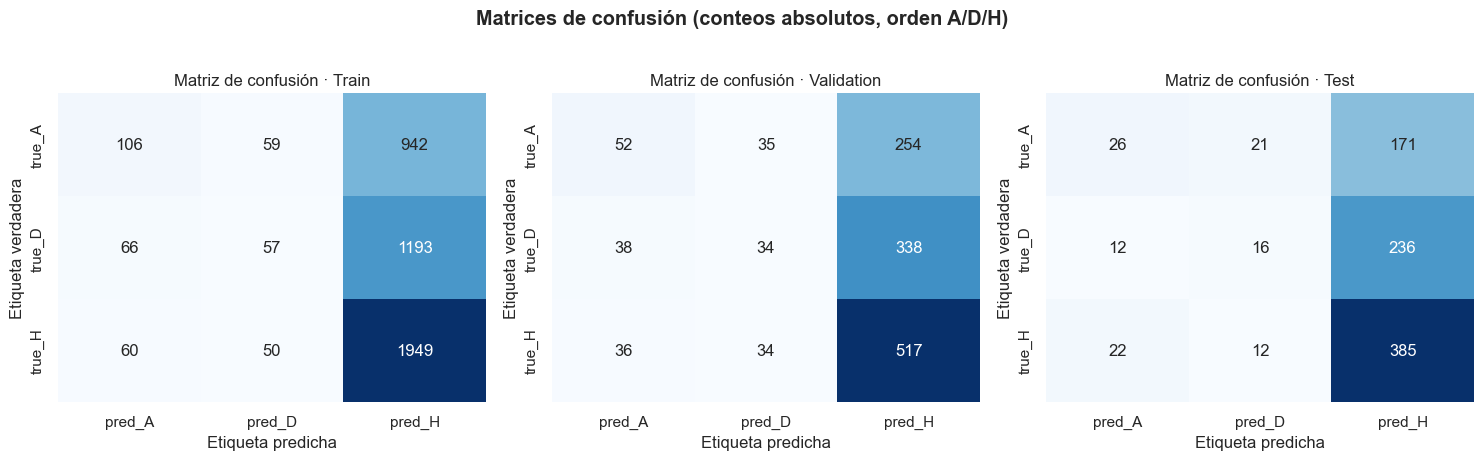

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, resultado) in zip(
    axes,
    [('Train',      resultado_train),
     ('Validation', resultado_val),
     ('Test',       resultado_test)],
):
    cm = np.array(resultado['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)

plt.suptitle('Matrices de confusión (conteos absolutos, orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


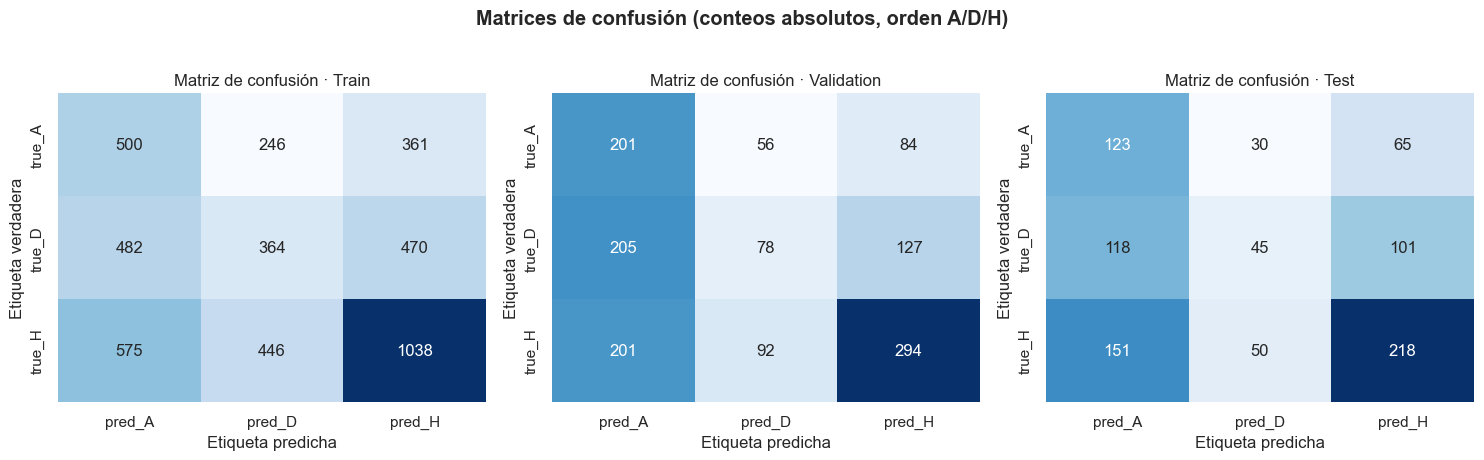

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (nombre, resultado) in zip(
    axes,
    [('Train',      resultado_train_balanced),
     ('Validation', resultado_val_balanced),
     ('Test',       resultado_test_balanced)],
):
    cm = np.array(resultado['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)

plt.suptitle('Matrices de confusión (conteos absolutos, orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


In [27]:
LABELS = ['A', 'D', 'H']
LOG_LOSS_MERCADO = 1.037

logreg_balanced = LogisticRegression(
    random_state=SEED, max_iter=5000, solver='lbfgs',
    penalty='l2', C=0.001, class_weight='balanced',
).fit(X_train, y_train)

logreg_simple = LogisticRegression(
    random_state=SEED, max_iter=5000, solver='lbfgs',
    penalty='l2', C=0.001, class_weight=None,
).fit(X_train, y_train)

def evaluar_split(modelo, nombre_modelo, nombre_split, X, y):
    y_pred  = modelo.predict(X)
    y_proba = pd.DataFrame(
        modelo.predict_proba(X),
        columns=modelo.classes_,
    )[LABELS].values
    res = evaluar_modelo(y, y_pred, y_proba,
                         f'{nombre_modelo} · {nombre_split}',
                         verbose=False)
    res['variante'] = nombre_modelo
    res['split']    = nombre_split
    return res

filas = []
for nombre_modelo, modelo in [('Balanced', logreg_balanced),
                              ('Sin pesos', logreg_simple)]:
    for nombre_split, X, y in [('train', X_train, y_train),
                                ('validation', X_val, y_val),
                                ('test', X_test, y_test)]:
        filas.append(evaluar_split(modelo, nombre_modelo, nombre_split, X, y))

tabla = (pd.DataFrame(filas)
         [['variante', 'split', 'accuracy', 'f1_macro',
           'f1_A', 'f1_D', 'f1_H', 'log_loss']]
         .assign(delta_vs_mercado=lambda d: d['log_loss'] - LOG_LOSS_MERCADO))

print(tabla.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


 variante      split  accuracy  f1_macro   f1_A   f1_D   f1_H  log_loss  delta_vs_mercado
 Balanced      train    0.4244    0.4036 0.3754 0.3069 0.5285    1.0700            0.0330
 Balanced validation    0.4283    0.4026 0.4241 0.2453 0.5385    1.0708            0.0338
 Balanced       test    0.4284    0.3925 0.4033 0.2314 0.5430    1.0706            0.0336
Sin pesos      train    0.4712    0.2899 0.1583 0.0769 0.6345    1.0357           -0.0013
Sin pesos validation    0.4507    0.3216 0.2227 0.1326 0.6097    1.0397            0.0027
Sin pesos       test    0.4739    0.3084 0.1871 0.1022 0.6358    1.0312           -0.0058


In [ ]:
coef_df = pd.DataFrame(
    logreg_simple.coef_,
    index=logreg_simple.classes_,
    columns=FEATURE_COLS,
).T
print("Top features por magnitud (sin pesos):")
print(coef_df.abs().sum(axis=1).sort_values(ascending=False))

Top features por magnitud (sin pesos):
prob_h               0.218287
match_uncertainty    0.112337
away_gc_3            0.079361
home_mv              0.062086
away_gd_pre          0.058611
away_mv              0.049603
home_gf_5            0.049585
away_gf_5            0.047226
away_elo_pre         0.045740
away_gf_3            0.042616
away_pts_pre         0.041818
away_gf_10           0.040115
home_rest_days       0.036765
home_ppg_3           0.035858
home_elo_pre         0.031903
away_rest_days       0.031875
home_gc_10           0.029911
away_ppg_3           0.029884
home_ppg_10          0.028825
home_gf_3            0.028665
home_gd_pre          0.027839
away_pos_pre         0.025830
away_ppg_5           0.021657
home_pts_pre         0.021627
home_ppg_5           0.014946
away_gc_5            0.014684
away_gc_10           0.013601
home_gc_3            0.010741
home_gf_10           0.010097
away_ppg_10          0.006017
home_gc_5            0.005267
home_pos_pre         0.005234
d

In [31]:
coef_df = pd.DataFrame(
    logreg_balanced.coef_,
    index=logreg_balanced.classes_,
    columns=FEATURE_COLS,
).T
print("Top features por magnitud (sin pesos):")
print(coef_df.abs().sum(axis=1).sort_values(ascending=False))

Top features por magnitud (sin pesos):
prob_h               0.209291
match_uncertainty    0.114564
away_gc_3            0.083115
away_gd_pre          0.062244
home_mv              0.059183
home_gf_5            0.051324
away_gf_3            0.048452
away_mv              0.047145
away_gf_10           0.045961
away_pts_pre         0.044940
away_gf_5            0.044353
away_elo_pre         0.043386
home_rest_days       0.038808
home_ppg_3           0.038778
home_elo_pre         0.034721
home_ppg_10          0.031540
home_gf_3            0.030847
away_ppg_3           0.030193
away_rest_days       0.030134
home_gc_10           0.028379
home_gd_pre          0.028127
away_pos_pre         0.026021
home_pts_pre         0.023073
away_ppg_5           0.022725
away_gc_5            0.016859
home_ppg_5           0.016757
away_gc_10           0.014489
home_gf_10           0.012500
home_gc_3            0.009882
home_pos_pre         0.009417
away_ppg_10          0.008734
home_gc_5            0.008290
d

In [29]:
joblib.dump(logreg_balanced, MODELS_DIR / 'logistic_regression_balanced.pkl')
joblib.dump(logreg_simple, MODELS_DIR / 'logistic_regression_simple.pkl')

['/Users/pedrosarm/Desktop/TFM/Code/notebooks/models/logistic_regression_simple.pkl']